# Giai đoạn 9: Trận chiến Cuối cùng (Advanced Features + TabPFN)
Áp dụng tập dữ liệu mạnh nhất hiện tại (Đã qua lọc SQI + 16 Đặc trưng bao gồm Phi tuyến tính) cho toàn bộ các mô hình, bao gồm cả một kiến trúc Foundation Model đột phá cho dữ liệu dạng bảng là **TabPFN** (Transformer).

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# --- Cài đặt TabPFN nếu chưa có ---
try:
    from tabpfn import TabPFNClassifier
except ImportError:
    print("Đang cài đặt thư viện TabPFN...")
    import subprocess
    import sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tabpfn'])
    from tabpfn import TabPFNClassifier

# Các thuật toán khác
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
import xgboost as xgb
import lightgbm as lgb

### 1. Load Tập dữ liệu Advanced (Non-linear) đã trích xuất từ file 07

In [8]:
data_path = '../../data/features/mimic_train_features_advanced.csv'
print("Đang đọc dữ liệu...", data_path)
df = pd.read_csv(data_path)

X = df.drop(columns=['status'])
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Tập Train: {len(X_train)} mẫu | Tập Test: {len(X_test)} mẫu")
print(f"Số lượng đặc trưng (Features): {X.shape[1]}")

Đang đọc dữ liệu... ../../data/features/mimic_train_features_advanced.csv
Tập Train: 961 mẫu | Tập Test: 241 mẫu
Số lượng đặc trưng (Features): 16


### 2. Định nghĩa 12 mô hình (Có TabPFN) và Huấn luyện đồng loạt

In [9]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    "Extra Trees": ExtraTreesClassifier(n_estimators=300, random_state=42, class_weight='balanced'),
    "SVM": SVC(random_state=42, probability=True),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "LDA": LinearDiscriminantAnalysis(),
    "QDA": QuadraticDiscriminantAnalysis(reg_param=0.1),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": lgb.LGBMClassifier(random_state=42, verbose=-1, n_estimators=300, learning_rate=0.05, num_leaves=31),
    # "TabPFN": TabPFNClassifier(device='cpu') # TabPFN không cần tuning, nó là Pre-trained model
}

results = []
confusion_matrices = {}

os.makedirs('../../models/advanced_compare', exist_ok=True)

for name, model in models.items():
    print(f"Đang huấn luyện: {name}...")
    
    # TabPFN tự chuẩn hoá dữ liệu ngầm, nhưng ta cứ đưa qua pipeline cho đồng bộ
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    
    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1
    })
    
    confusion_matrices[name] = confusion_matrix(y_test, y_pred)
    joblib.dump(pipeline, f"../../models/advanced_compare/{name.replace(' ', '_').lower()}.pkl")

print("\n✅ Huấn luyện hoàn tất 12 mô hình!")

Đang huấn luyện: Logistic Regression...
Đang huấn luyện: Decision Tree...
Đang huấn luyện: Random Forest...
Đang huấn luyện: Extra Trees...
Đang huấn luyện: SVM...
Đang huấn luyện: KNN...
Đang huấn luyện: Naive Bayes...
Đang huấn luyện: LDA...
Đang huấn luyện: QDA...
Đang huấn luyện: XGBoost...
Đang huấn luyện: LightGBM...

✅ Huấn luyện hoàn tất 12 mô hình!


### 3. Vẽ Lưới Confusion Matrix (3 Hàng x 4 Cột = 12 Mô hình)

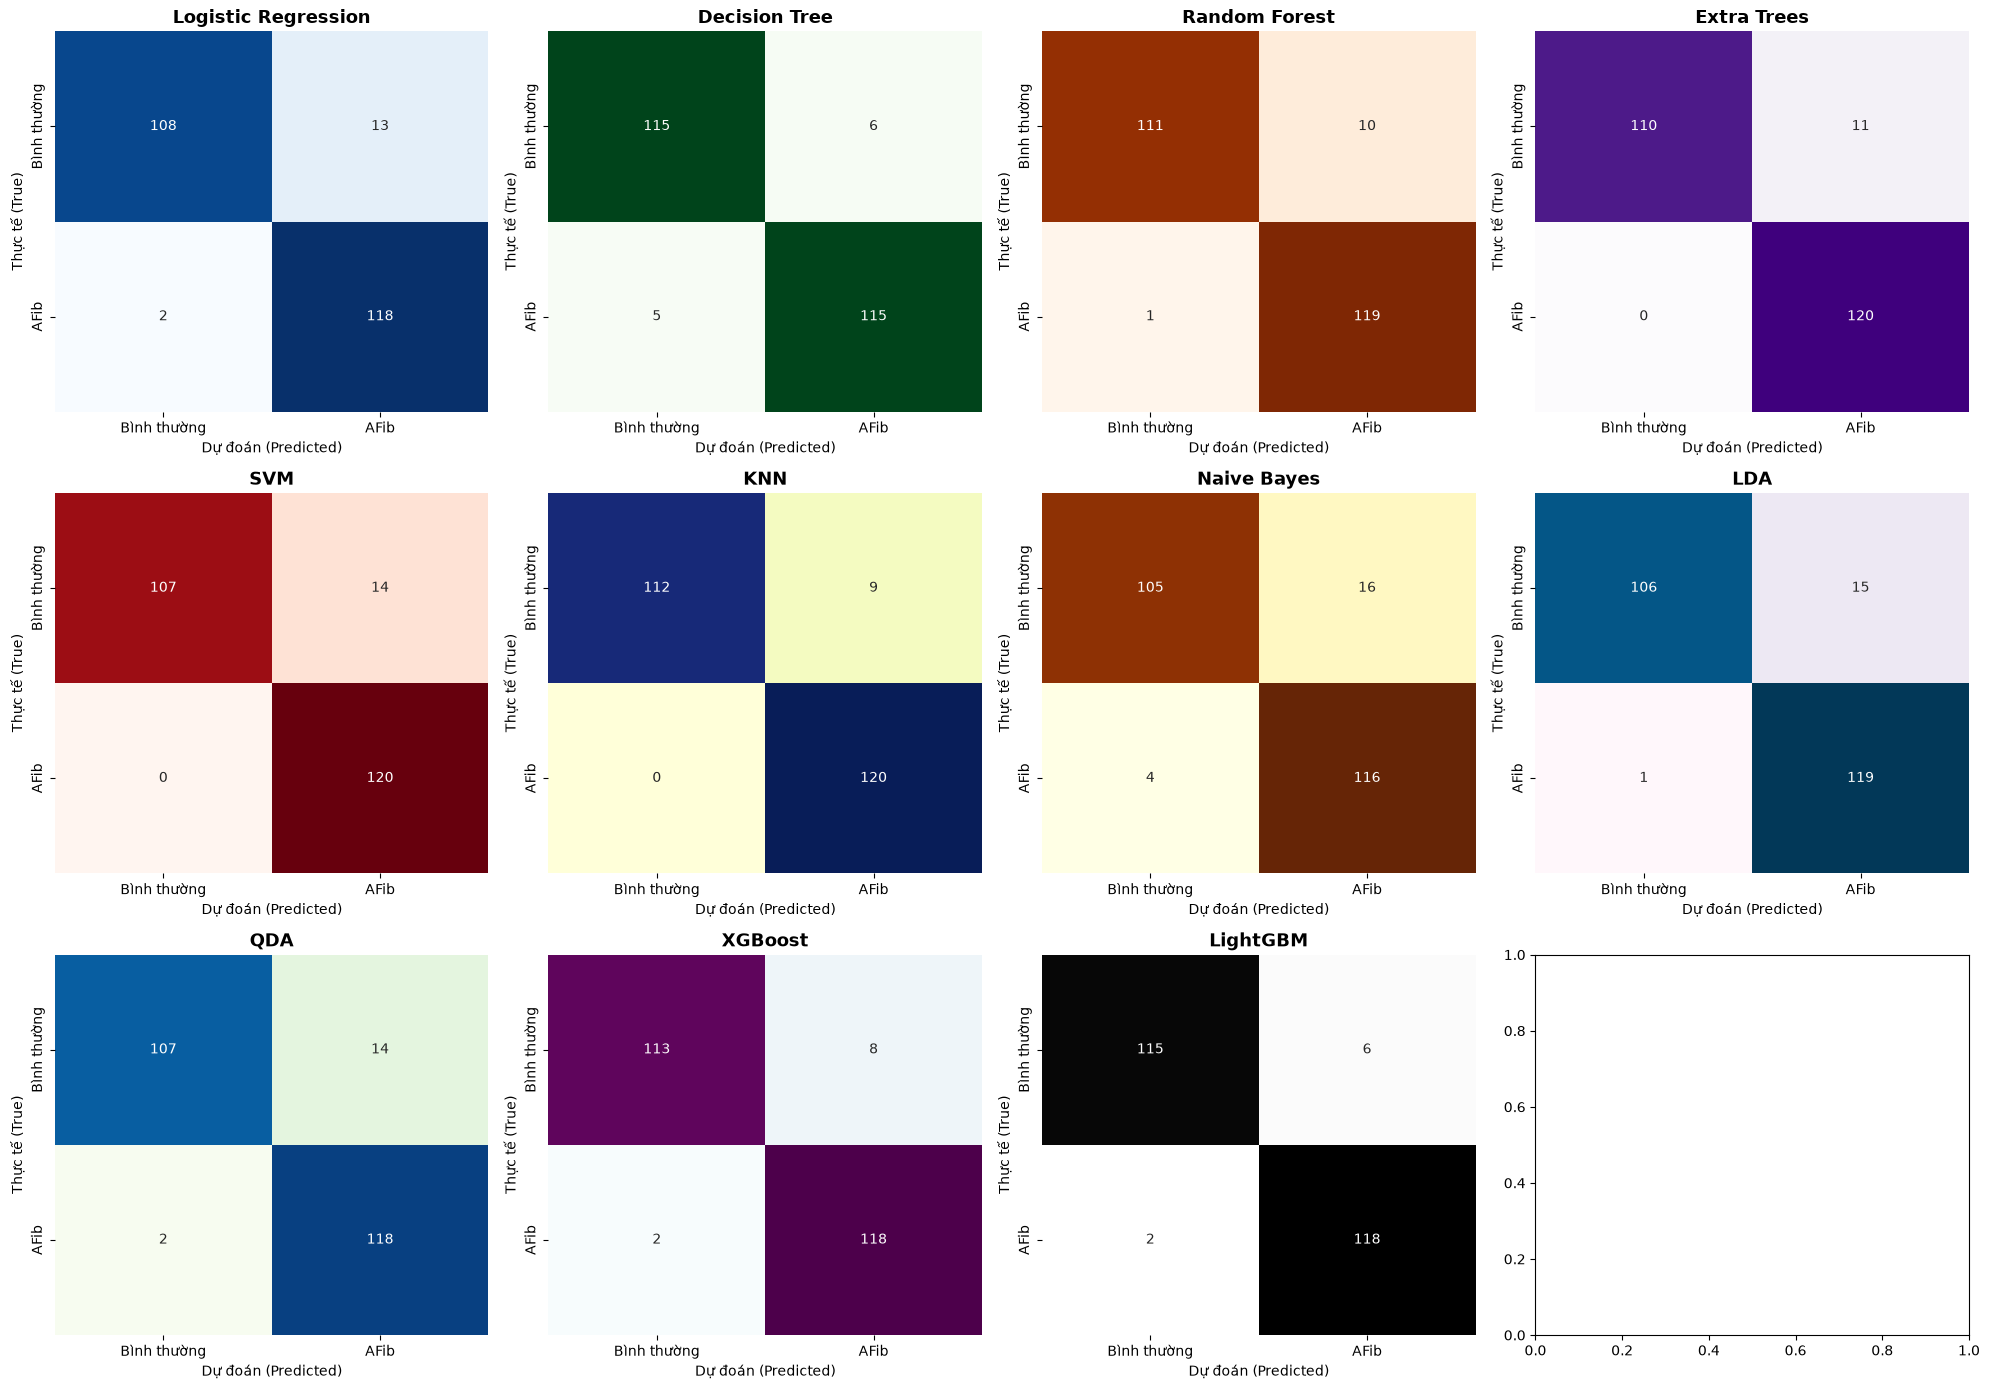

In [10]:
cmaps = ['Blues', 'Greens', 'Oranges', 'Purples', 'Reds', 
         'YlGnBu', 'YlOrBr', 'PuBu', 'GnBu', 'BuPu', 'Greys', 'PuRd']

fig, axes = plt.subplots(3, 4, figsize=(20, 14))
axes = axes.flatten()

for i, (name, cm) in enumerate(confusion_matrices.items()):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[i], ax=axes[i], cbar=False)
    axes[i].set_title(name, fontweight='bold', fontsize=13)
    axes[i].set_ylabel('Thực tế (True)', fontsize=10)
    axes[i].set_xlabel('Dự đoán (Predicted)', fontsize=10)
    axes[i].set_xticklabels(['Bình thường', 'AFib'])
    axes[i].set_yticklabels(['Bình thường', 'AFib'])

plt.tight_layout()
plt.show()

### 4. Bảng Xếp Hạng Accuracy Cuối Cùng

,Model,Accuracy,Precision,Recall,F1-Score
0,LightGBM,0.966805,0.951613,0.983333,0.967213
1,KNN,0.962656,0.930233,1.000000,0.963855
2,XGBoost,0.958506,0.936508,0.983333,0.959350
3,Decision Tree,0.954357,0.950413,0.958333,0.954357
4,Random Forest,0.954357,0.922481,0.991667,0.955823
5,Extra Trees,0.954357,0.916031,1.000000,0.956175
6,SVM,0.941909,0.895522,1.000000,0.944882
7,Logistic Regression,0.937759,0.900763,0.983333,0.940239
8,QDA,0.933610,0.893939,0.983333,0.936508
9,LDA,0.933610,0.888060,0.991667,0.937008


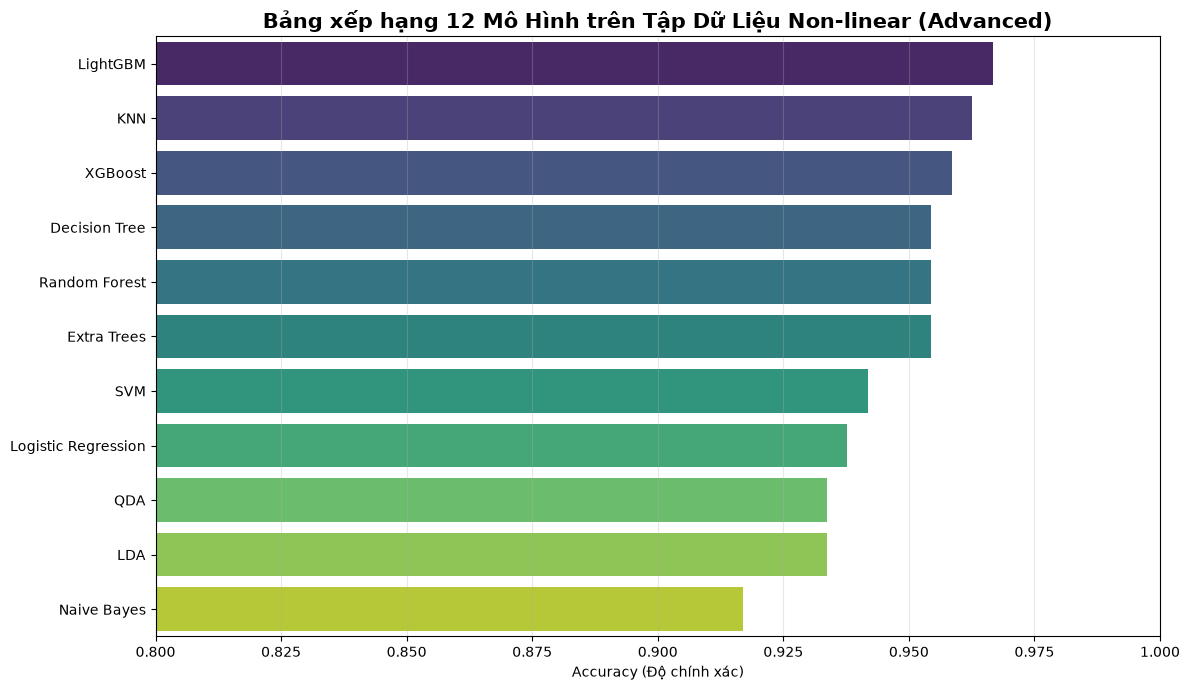

In [11]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

display(results_df)

plt.figure(figsize=(12, 7))
sns.barplot(data=results_df, x="Accuracy", y="Model", palette="viridis")
plt.title("Bảng xếp hạng 12 Mô Hình trên Tập Dữ Liệu Non-linear (Advanced)", fontsize=15, fontweight='bold')
plt.xlabel("Accuracy (Độ chính xác)")
plt.ylabel("")
plt.xlim([0.8, 1.0])
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()